# Scripts for plotting 

## Set the environment

First, create an environment with the necessary packages:
- metpy
- cartopy
- wrf-python
- netCDF4

Use the following command line to install them:
> conda install -c conda-forge package_name

or 

> %pip install metpy

Notes: 
1. to install wrf-python you must have a python version <= 3.11 !
2. for MacOS you need to install wrf-python from source code (ask Simona how to do it).

## Import libraries

In [9]:
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
import metpy
import metpy.calc as mpcalc
from metpy.units import units

from matplotlib.cm import get_cmap
import cartopy.crs as crs
from cartopy.feature import NaturalEarthFeature
from netCDF4 import Dataset

from wrf import to_np, getvar, CoordPair, vertcross, interpline

#Additional package to ignore warning
import warnings
warnings.filterwarnings('ignore')

## Inspect the sounding

In [ ]:
sounding = '2025/basic_case/input_sounding'                       # insert name of the sounding file
delimiter = '\s+'
df = pd.read_table(sounding, delimiter=delimiter, names = ["height","potential temperature (K)", "mixing ratio (g/kg)", "u (m/s)", "v (m/s)"])
df = df.drop([0])                   # first line is surface variables

# Add units to the dataset
heights = units.Quantity(df['height'].values.astype(float),'meters')
temperatures = units.Quantity(df['potential temperature (K)'].values.astype(float),'K')
u = units.Quantity(df['u (m/s)'].values.astype(float),'m/s')

df

### Plot sounding (Vertical profile of potential temperature)

In [ ]:
fig, ax = plt.subplots(figsize=(4,6))

plt.plot(df["potential temperature (K)"],df["height"])

# Add minor ticks on y axis
ax = plt.gca()                                         # Select current axis
ax.minorticks_on()                                     # Enable minor ticks on both axis
ax.yaxis.set_minor_locator(ticker.AutoMinorLocator())  # Optionally, adjust the spacing of the minor ticks

# Add a horizontal line at the height of the mountain
plt.axhline(y = 100, color = 'r', linestyle = '--', label = "mountain height")       # remember to change y value to match hill heigth

# plotting the legend 
#plt.legend(bbox_to_anchor = (1.0, 1), loc = 'upper right') 

ax.text(0.95, 0.015, 'ridge height', verticalalignment='bottom', horizontalalignment='right', transform=ax.transAxes, color='red', fontsize=10)

ax.set_ylim(0, 10000)
ax.set_xlim(270, 320)

plt.title('Vertical profile of Potential Temperature (K)')
plt.xlabel('theta (K)')
plt.ylabel('z (m)')
plt.grid(linestyle='--')
plt.show()

In [ ]:
# --- Calculation of Brunt Vaisala frequency

# 1) Uniform atmosphere: met.calc calculates BVf in each level, if atmosphere is uniform you can average it
bvf = metpy.calc.brunt_vaisala_frequency(heights,temperatures)
print(bvf)

# 2) When atmosphere is layered you can calculate bvf for each layer
# bvf1 = metpy.calc.brunt_vaisala_frequency(heights[:40],temperatures[:40])        # select the level
# bvf2 = metpy.calc.brunt_vaisala_frequency(heights[41:60],temperatures[41:60])        # select the level

# bvf1 = np.mean(bvf1)
# bvf2 = np.mean(bvf2)

# print(bvf1,bvf2)

#print('Brunt Vaisala frequency is', bvf1, bvf2)

In [ ]:
# Froude number calculation

hill_heigth = 1000 * units.meters                   # change hill heigth accordingly to your case

froude = u[0] / (bvf * hill_heigth)

print('Froude number is', froude)

## Cross sections (u,w,theta)

We use the wrf outputs to plot fields of interest.
To plot, we use wrf-python (https://wrf-python.readthedocs.io/en/latest/index.html), a collection of routines to analyse wrf ouputs.

Here a list of variables already made: https://wrf-python.readthedocs.io/en/latest/diagnostics.html

In [11]:
# First, you need to import the file

ncfile = Dataset('./wrfout_100.nc')   # import netcdf file

# You can then inspect the file:
ncfile

<class 'netCDF4.Dataset'>
root group (NETCDF3_64BIT_OFFSET data model, file format NETCDF3):
    TITLE:  OUTPUT FROM WRF V4.7.1 MODEL
    START_DATE: 0001-01-01_00:00:00
    SIMULATION_START_DATE: 0001-01-01_00:00:00
    WEST-EAST_GRID_DIMENSION: 202
    SOUTH-NORTH_GRID_DIMENSION: 3
    BOTTOM-TOP_GRID_DIMENSION: 41
    DX: 2000.0
    DY: 2000.0
    AERCU_OPT: 0
    AERCU_FCT: 1.0
    IDEAL_CASE: 1
    DIFF_6TH_SLOPEOPT: 0
    AUTO_LEVELS_OPT: 2
    DIFF_6TH_THRESH: 0.1
    DZBOT: 50.0
    DZSTRETCH_S: 1.3
    DZSTRETCH_U: 1.1
    SKEBS_ON: 0
    USE_Q_DIABATIC: 0
    GRIDTYPE: C
    DIFF_OPT: 2
    KM_OPT: 1
    DAMP_OPT: 3
    DAMPCOEF: 0.1
    KHDIF: 0.0
    KVDIF: 0.0
    MP_PHYSICS: 0
    RA_LW_PHYSICS: 0
    RA_SW_PHYSICS: 0
    SF_SFCLAY_PHYSICS: 0
    SF_SURFACE_PHYSICS: 0
    BL_PBL_PHYSICS: 0
    CU_PHYSICS: 0
    SF_LAKE_PHYSICS: 0
    SURFACE_INPUT_SOURCE: 3
    SST_UPDATE: 0
    GHG_INPUT: 0
    GRID_FDDA: 0
    GFDDA_INTERVAL_M: 0
    GFDDA_END_H: 0
    GRID_SFDDA: 0
   

In [3]:
# To extract variables (see the list of available diagnostic variables https://wrf-python.readthedocs.io/en/latest/diagnostics.html)

z = getvar(ncfile, "z", timeidx=-1)          # model height (relative to msl)
ter = getvar(ncfile, "ter", timeidx=-1)      # model terrain height

# Inspect the variables:
z

<xarray.DataArray 'height' (bottom_top: 40, south_north: 2, west_east: 201)> Size: 64kB
array([[[  400.81216,   400.8171 ,   400.8221 , ...,   400.84808,
           400.843  ,   400.83817],
        [  400.81216,   400.8171 ,   400.8221 , ...,   400.84808,
           400.843  ,   400.83817]],

       [[ 1195.1952 ,  1195.1997 ,  1195.2045 , ...,  1195.288  ,
          1195.2823 ,  1195.278  ],
        [ 1195.1952 ,  1195.1997 ,  1195.2045 , ...,  1195.288  ,
          1195.2823 ,  1195.278  ]],

       [[ 1976.214  ,  1976.218  ,  1976.2219 , ...,  1976.3348 ,
          1976.3279 ,  1976.3231 ],
        [ 1976.214  ,  1976.218  ,  1976.2219 , ...,  1976.3348 ,
          1976.3279 ,  1976.3231 ]],

       ...,

       [[25347.098  , 25347.098  , 25347.1    , ..., 25347.16   ,
         25347.16   , 25347.16   ],
        [25347.098  , 25347.098  , 25347.1    , ..., 25347.16   ,
         25347.16   , 25347.16   ]],

       [[26583.107  , 26583.11   , 26583.111  , ..., 26583.121  ,
         26583.121  , 26583.121  ],
        [26583.107  , 26583.11   , 26583.111  , ..., 26583.121  ,
         26583.121  , 26583.121  ]],

       [[28476.28   , 28476.28   , 28476.285  , ..., 28476.209  ,
         28476.209  , 28476.209  ],
        [28476.28   , 28476.28   , 28476.285  , ..., 28476.209  ,
         28476.209  , 28476.209  ]]], dtype=float32)
Coordinates:
    XLONG    (south_north, west_east) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    XLAT     (south_north, west_east) float32 2kB 0.0 0.0 0.0 ... 0.0 0.0 0.0
    XTIME    float32 4B 600.0
    Time     datetime64[ns] 8B 1754-08-31T08:43:41.128654848
Dimensions without coordinates: bottom_top, south_north, west_east
Attributes:
    FieldType:    104
    MemoryOrder:  XYZ
    description:  model height - [MSL] (mass grid)
    units:        m
    stagger:      
    coordinates:  XLONG XLAT XTIME
    projection:   RotatedLatLon(stand_lon=0.0, moad_cen_lat=0.0, truelat1=0.0...

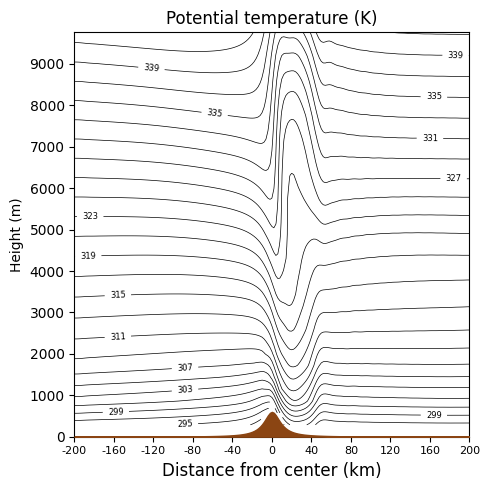

In [ ]:
# Plot vertical cross section of perturbation potential temperature

ds = Dataset('./wrfout_600_sound1.nc')

pt_i = getvar(ds, 'theta', timeidx=0)
pt_fin = getvar(ds, 'theta', timeidx=-1)
hgt = getvar(ds, 'HGT', timeidx=0)
z = getvar(ds, 'z', units='m', timeidx=10)   # height MSL
z = z - np.min(z)

# Define a start point and end point in grid coordinates
start_point = CoordPair(x=0, y=0)           # change the x to zoom on a specific area (remember that the hill is at the center of the domain)
end_point = CoordPair(x=200, y=0)

hgt_xs = interpline(hgt, start_point=start_point, end_point=end_point, latlon=False)

#Calculate the vertical cross section.
pt_pert = pt_fin - pt_i                     # perturbation potential temperature
pt_vert = vertcross(pt_fin, z, start_point=start_point, end_point=end_point, latlon=False)

fig, ax = plt.subplots(figsize=(5, 5))

# Coordinates
x = np.arange(pt_vert.shape[-1])
y = to_np(pt_vert.coords["vertical"][:35])                  # limit to 35 levels for better visualization
X, Y = np.meshgrid(x, y)

terrain = to_np(hgt_xs)
terrain2d = np.tile(terrain, (Y.shape[0], 1))

# Mask below terrain
pt_masked = np.ma.masked_where(Y < terrain2d, to_np(pt_vert[:35]))

# Plot contours
pt_levels = np.arange(np.floor(pt_masked.min()), np.ceil(pt_masked.max()) + 1, 2.0)             # isentropes every 2K
pt_contours = ax.contour(X, Y, pt_masked, levels=pt_levels, colors='k', linewidths=0.5)
ax.clabel(pt_contours, levels=pt_levels[::2], inline=True, fontsize=6)
ax.set_title("Potential temperature (K)")

# Terrain
ax.fill_between(x, terrain, terrain.min(), color='saddlebrown', zorder=10)

# Y axis
ax.set_ylim(terrain.min(), y.max())
y_ticks = np.arange(0, y.max()+1, 1000)
ax.set_yticks(y_ticks)
ax.set_ylabel("Height (m)")

# Set the x-ticks as distance in km from center
dx = 2000                                                                         # Grid spacing in meters
num_points = to_np(pt_vert).shape[-1]
x_vals_km = np.arange(num_points) * (dx / 1000.0)                                 # distance from start in km
x_center_km = x_vals_km[-1] / 2
x_labels_km = x_vals_km - x_center_km
ax.set_xticks(np.arange(0, num_points, 20))
ax.set_xticklabels([f"{x:.0f}" for x in x_labels_km[::20]], fontsize=8)
ax.set_xlabel("Distance from center (km)", fontsize=12)

plt.tight_layout()
plt.show()

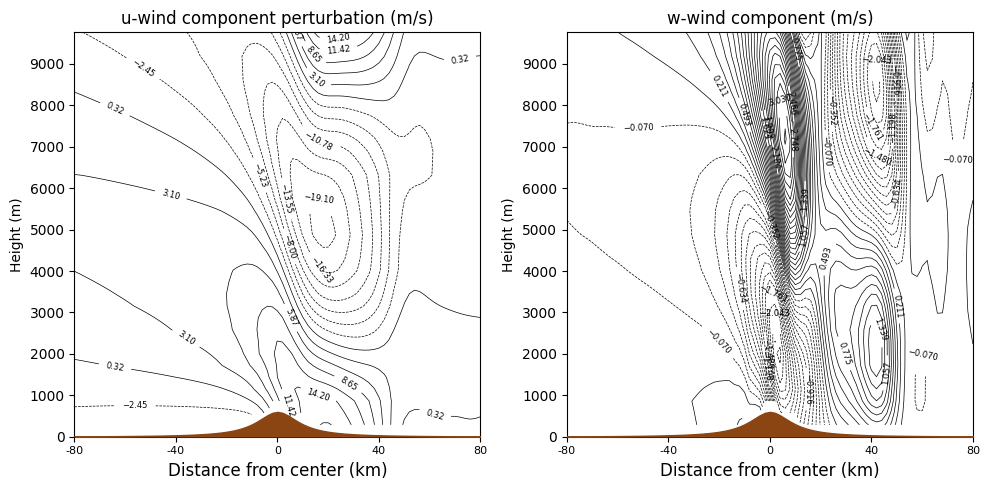

In [16]:
# Plot vertical cross section of wind components

ds = Dataset('./wrfout_600_sound1.nc')

u_0 = getvar(ds, 'ua', units='m/s', timeidx=0)
u = getvar(ds, 'ua', units='m/s', timeidx=-1)
w = getvar(ds, 'wa', units='m/s', timeidx=-1)
hgt = getvar(ds, 'HGT', timeidx=0)
z = getvar(ds, 'z', units='m', timeidx=10)   # height MSL
z = z - np.min(z)

# Define a start point and end point in grid coordinates
start_point = CoordPair(x=60, y=0)
end_point = CoordPair(x=140, y=0)

hgt_xs = interpline(hgt, start_point=start_point, end_point=end_point, latlon=False)

#Calculate the vertical cross section.
u_diff = u - u_0
u_vert = vertcross(u_diff, z, start_point=start_point, end_point=end_point, latlon=False)
w_vert = vertcross(w, z, start_point=start_point, end_point=end_point, latlon=False)

fig, ax = plt.subplots(1, 2, figsize=(10, 5))

# Coordinates
x = np.arange(u_vert.shape[-1])
y = to_np(u_vert.coords["vertical"][:35])
X, Y = np.meshgrid(x, y)

terrain = to_np(hgt_xs)
terrain2d = np.tile(terrain, (Y.shape[0], 1))

# Mask below terrain
u_masked = np.ma.masked_where(Y < terrain2d, to_np(u_vert[:35]))
w_masked = np.ma.masked_where(Y < terrain2d, to_np(w_vert[:35]))

# Plot contours
# u_levels = np.arange(-2,2.1,0.25)
# u_levels = np.delete(u_levels,8,0)      # eliminate contour at 0
u_min, u_max = to_np(u_vert).min(), to_np(u_vert).max()
u_levels = np.linspace(u_min,u_max,20).round(2)
u_contours = ax[0].contour(X, Y, u_masked, levels=u_levels, colors='k', linewidths=0.5)
ax[0].clabel(u_contours, inline=True, fontsize=6)
ax[0].set_title("u-wind component perturbation (m/s)")

w_min, w_max = to_np(w_vert).min(), to_np(w_vert).max()
w_levels = np.linspace(w_min, abs(w_min)).round(3)
# w_contours = ax[1].contourf(to_np(w_vert), levels=w_levels, cmap=get_cmap("bwr"))
# plt.colorbar(w_contours, ax=ax[1])
w_contours = ax[1].contour(X, Y, w_masked, levels=w_levels, colors='k', linewidths=0.5)
ax[1].clabel(w_contours, levels=w_levels[::2], inline=True, fontsize=6)
ax[1].set_title("w-wind component (m/s)")

# Set features common at both plots
for a in ax:
    
    # Terrain
    a.fill_between(x, terrain, terrain.min(), color='saddlebrown', zorder=10)

    # Y axis
    a.set_ylim(terrain.min(), y.max())
    y_ticks = np.arange(0, y.max()+1, 1000)
    a.set_yticks(y_ticks)
    a.set_ylabel("Height (m)")
    
    # Set the x-ticks as distance in km from center
    dx = 2000                                                                         # Grid spacing in meters
    num_points = to_np(u_vert).shape[-1]
    x_vals_km = np.arange(num_points) * (dx / 1000.0)                                 # distance from start in km
    x_center_km = x_vals_km[-1] / 2
    x_labels_km = x_vals_km - x_center_km
    a.set_xticks(np.arange(0, num_points, 20))
    a.set_xticklabels([f"{x:.0f}" for x in x_labels_km[::20]], fontsize=8)
    a.set_xlabel("Distance from center (km)", fontsize=12)

plt.tight_layout()
plt.show()